## Notebook 2 — Adaptive Trend Following with Multi-Horizon Signals

In Notebook 1, we showed that a simple 12-month time-series momentum signal is a strong baseline: it is intuitive, robust, and easy to implement. But it is also slow. Because it relies on a long lookback window, it can react late when trends reverse.

This notebook studies whether we can make trend following more responsive without making it too noisy.

The main idea is simple: instead of using only 12-month momentum, we combine signals from multiple horizons such as 1, 3, 6, and 12 months. Shorter horizons may react faster, while longer horizons help anchor the signal. The goal is to see whether this combination improves responsiveness, drawdowns, or regime awareness relative to the 12-month baseline.

We begin with sign-based signals for simplicity and interpretability. For each horizon (k), we compute the trailing return (R_{k,t}) and define:

$$
s_{k,t} = \operatorname{sign}(R_{k,t})
$$

We then combine these horizon signals into a single adaptive trend score. The central model in this notebook is:

$$
\text{score}_t = \frac{1}{4}\left(
\operatorname{sign}(R_{1,t}) +
\operatorname{sign}(R_{3,t}) +
\operatorname{sign}(R_{6,t}) +
\operatorname{sign}(R_{12,t})
\right)
$$

and we trade the lagged score:

$$
p_t = \text{score}_{t-1}
$$

This creates a simple multi-horizon trend rule: when all horizons agree, exposure is strong; when they disagree, exposure is reduced. That makes the score both a trend signal and a measure of conviction.

The goal of this notebook is to compare single-horizon and combined-horizon signals, and to test whether disagreement across horizons contains useful regime information.

*Below, the code implements **per-horizon** sign rules first; the averaged score above is the natural next step.*

In [15]:
import pandas as pd
from helpers.data_utils import load_yahoo_close, daily_to_month_end, month_end_to_returns
from helpers.signal_utils import trailing_return, sign_signal
from helpers.backtest_utils import position_from_signal, strategy_returns, position_counts, position_summary, cumulative_returns, drawdown, perf_stats, compare_perf_stats
from helpers.plot_utils import plot_tsmom_diagnostics
from IPython.display import display, HTML
import matplotlib.pyplot as plt

tickers = ["SPY", "BIL", "IEF", "TLT", "GLD", "BTC-USD"]

daily_prices = {}

for ticker in tickers:
    daily_prices[ticker] = load_yahoo_close(ticker, data_dir="data/daily", refresh=False)

print("Downloaded / loaded tickers:")
for ticker, px in daily_prices.items():
    print(f"{ticker}: {px.index.min().date()} -> {px.index.max().date()} | rows={len(px)}")

Loaded SPY from cache: data/daily/SPY_adj_close.csv | rows=8350
Loaded BIL from cache: data/daily/BIL_adj_close.csv | rows=4741
Loaded IEF from cache: data/daily/IEF_adj_close.csv | rows=5957
Loaded TLT from cache: data/daily/TLT_adj_close.csv | rows=5957
Loaded GLD from cache: data/daily/GLD_adj_close.csv | rows=5375
Loaded BTC-USD from cache: data/daily/BTC-USD_adj_close.csv | rows=4216
Downloaded / loaded tickers:
SPY: 1993-01-29 -> 2026-04-01 | rows=8350
BIL: 2007-05-30 -> 2026-04-01 | rows=4741
IEF: 2002-07-30 -> 2026-04-01 | rows=5957
TLT: 2002-07-30 -> 2026-04-01 | rows=5957
GLD: 2004-11-18 -> 2026-04-01 | rows=5375
BTC-USD: 2014-09-17 -> 2026-04-02 | rows=4216


### Data

Load adjusted closes from cache (`data/daily/`), build a **daily panel**, then inspect **coverage** (start/end, counts). Month-end prices and returns use the same helpers as Notebook 1.


In [16]:
daily_px = pd.concat(daily_prices, axis=1)
daily_px.tail()

,SPY,BIL,IEF,TLT,GLD,BTC-USD
Date,,,,,,
2026-03-29,NaN,NaN,NaN,NaN,NaN,65954.921875
2026-03-30,631.969971,91.375999,95.269997,86.434639,414.579987,66691.445312
2026-03-31,650.340027,91.375999,95.440002,86.345001,430.290009,68233.312500
2026-04-01,655.239990,91.400002,95.040001,86.260002,437.820007,68078.554688
2026-04-02,NaN,NaN,NaN,NaN,NaN,66426.734375


In [17]:
daily_ranges = pd.DataFrame({
    "start": daily_px.apply(lambda col: col.dropna().index.min()),
    "end": daily_px.apply(lambda col: col.dropna().index.max()),
    "n_obs": daily_px.notna().sum()
})

daily_ranges

,start,end,n_obs
SPY,1993-01-29,2026-04-01,8350
BIL,2007-05-30,2026-04-01,4741
IEF,2002-07-30,2026-04-01,5957
TLT,2002-07-30,2026-04-01,5957
GLD,2004-11-18,2026-04-01,5375
BTC-USD,2014-09-17,2026-04-02,4216


In [18]:
# Daily panel -> month-end panel
px_m = daily_to_month_end(daily_px)

# Month-end panel -> monthly returns panel
r_m = month_end_to_returns(px_m)

print("Month-end prices shape:", px_m.shape)
print("Monthly returns shape:", r_m.shape)

display(px_m.tail())
display(r_m.tail())

Month-end prices shape: (400, 6)
Monthly returns shape: (400, 6)


,SPY,BIL,IEF,TLT,GLD,BTC-USD
Date,,,,,,
2025-12-31,680.062744,90.603401,95.570480,86.195717,396.309998,87508.828125
2026-01-31,690.085327,90.871109,95.351830,86.166046,444.950012,78621.117188
2026-02-28,684.121643,91.113762,97.707001,90.158760,483.750000,66995.859375
2026-03-31,650.340027,91.375999,95.440002,86.345001,430.290009,68233.312500
2026-04-30,655.239990,91.400002,95.040001,86.260002,437.820007,66426.734375


,SPY,BIL,IEF,TLT,GLD,BTC-USD
Date,,,,,,
2025-12-31,0.000798,0.003352,-0.007612,-0.026586,0.021734,-0.031921
2026-01-31,0.014738,0.002955,-0.002288,-0.000344,0.122732,-0.101564
2026-02-28,-0.008642,0.002670,0.024700,0.046337,0.087201,-0.147864
2026-03-31,-0.049380,0.002878,-0.023202,-0.042300,-0.110512,0.018471
2026-04-30,0.007534,0.000263,-0.004191,-0.000984,0.017500,-0.026476


In [19]:
monthly_price_ranges = pd.DataFrame({
    "start": px_m.apply(lambda col: col.dropna().index.min()),
    "end": px_m.apply(lambda col: col.dropna().index.max()),
    "n_obs": px_m.notna().sum()
})

monthly_price_ranges

,start,end,n_obs
SPY,1993-01-31,2026-04-30,400
BIL,2007-05-31,2026-04-30,228
IEF,2002-07-31,2026-04-30,286
TLT,2002-07-31,2026-04-30,286
GLD,2004-11-30,2026-04-30,258
BTC-USD,2014-09-30,2026-04-30,140


### Multi-horizon signals

For each $k \in \{1,3,6,12\}$: trailing $k$-month return on **monthly** returns, then $s_{k,t} = \operatorname{sign}(\cdot)$. The SPY **sanity-check** table below compares $r_m$, trailings, and signs.


In [20]:
horizons = [1, 3, 6, 12]

trailing_returns = {}
signals = {}

for k in horizons:
    trailing_returns[k] = trailing_return(r_m, k)
    signals[k] = sign_signal(trailing_returns[k])

print("Built trailing returns for horizons:", horizons)
print("Built sign signals for horizons:", horizons)

display(trailing_returns[12].tail())
display(signals[12].tail())

Built trailing returns for horizons: [1, 3, 6, 12]
Built sign signals for horizons: [1, 3, 6, 12]


,SPY,BIL,IEF,TLT,GLD,BTC-USD
Date,,,,,,
2025-12-31,0.177191,0.041471,0.080320,0.042472,0.636765,-0.063367
2026-01-31,0.163298,0.040905,0.071243,0.037007,0.720877,-0.232253
2026-02-28,0.168073,0.040316,0.067807,0.026575,0.837467,-0.205956
2026-03-31,0.175915,0.039910,0.039478,-0.004862,0.493337,-0.173420
2026-04-30,0.195137,0.036656,0.024303,0.007870,0.441288,-0.294888


,SPY,BIL,IEF,TLT,GLD,BTC-USD
Date,,,,,,
2025-12-31,1.0,1.0,1.0,1.0,1.0,-1.0
2026-01-31,1.0,1.0,1.0,1.0,1.0,-1.0
2026-02-28,1.0,1.0,1.0,1.0,1.0,-1.0
2026-03-31,1.0,1.0,1.0,-1.0,1.0,-1.0
2026-04-30,1.0,1.0,1.0,1.0,1.0,-1.0


In [21]:
# Sanity check

ticker = "SPY"

pd.concat(
    {
        "r_1m": r_m[ticker],
        "trailing_1m": trailing_returns[1][ticker],
        "signal_1m": signals[1][ticker],
        "trailing_3m": trailing_returns[3][ticker],
        "signal_3m": signals[3][ticker],
        "trailing_6m": trailing_returns[6][ticker],
        "signal_6m": signals[6][ticker],
        "trailing_12m": trailing_returns[12][ticker],
        "signal_12m": signals[12][ticker],
    },
    axis=1
).tail(15)

,r_1m,trailing_1m,signal_1m,trailing_3m,signal_3m,trailing_6m,signal_6m,trailing_12m,signal_12m
Date,,,,,,,,,
2025-02-28,-0.012695,-0.012695,-1.0,-0.010572,-1.0,0.060901,1.0,0.184463,1.0
2025-03-31,-0.055719,-0.055719,-1.0,-0.042669,-1.0,-0.018821,-1.0,0.083048,1.0
2025-04-30,-0.008670,-0.008670,-1.0,-0.075790,-1.0,-0.018570,-1.0,0.118765,1.0
2025-05-31,0.062845,0.062845,1.0,-0.005078,-1.0,-0.015596,-1.0,0.131827,1.0
2025-06-30,0.051386,0.051386,1.0,0.107772,1.0,0.060505,1.0,0.149435,1.0
2025-07-31,0.023032,0.023032,1.0,0.143197,1.0,0.056555,1.0,0.161839,1.0
2025-08-31,0.020519,0.020519,1.0,0.097672,1.0,0.092098,1.0,0.158608,1.0
2025-09-30,0.035620,0.035620,1.0,0.081212,1.0,0.197736,1.0,0.175194,1.0
2025-10-31,0.023837,0.023837,1.0,0.082064,1.0,0.237013,1.0,0.214041,1.0


### Backtest and horizon comparison

**Positions**: use the signal from month $t-1$ at month $t$ (`lag=1`, no lookahead). **Returns**: `position * asset_return` for each ticker and horizon. **Tables**: buy-and-hold vs **1m / 3m / 6m / 12m** TSMOM (CAGR, Sharpe, max drawdown, hit rate).


In [22]:
positions = {}
strategy_returns_by_horizon = {}
stats_by_horizon = {}

asset_stats = r_m.apply(lambda col: perf_stats(col), axis=0).T

for k in horizons:
    positions[k] = position_from_signal(signals[k], lag=1)
    strategy_returns_by_horizon[k] = strategy_returns(positions[k], r_m)
    stats_by_horizon[k] = strategy_returns_by_horizon[k].apply(
        lambda col: perf_stats(col), axis=0
    ).T

metrics = ["CAGR", "Sharpe", "Max Drawdown", "Hit Rate"]

comparison_tables = {
    metric: pd.concat(
        {
            "Asset": asset_stats[metric],
            **{f"{k}m": stats_by_horizon[k][metric] for k in horizons}
        },
        axis=1
    )
    for metric in metrics
}

tables_html = f"""
<div style="display:grid; grid-template-columns: 1fr 1fr; gap: 24px; align-items:start;">
  <div style="overflow-x:auto;">
    <h4>CAGR</h4>
    {comparison_tables["CAGR"].to_html()}
  </div>
  <div style="overflow-x:auto;">
    <h4>Sharpe</h4>
    {comparison_tables["Sharpe"].to_html()}
  </div>
  <div style="overflow-x:auto;">
    <h4>Max Drawdown</h4>
    {comparison_tables["Max Drawdown"].to_html()}
  </div>
  <div style="overflow-x:auto;">
    <h4>Hit Rate</h4>
    {comparison_tables["Hit Rate"].to_html()}
  </div>
</div>
"""

display(HTML(tables_html))

,Asset,1m,3m,6m,12m
SPY,0.104329,0.009168,0.037665,0.073222,0.098995
BIL,0.013281,0.012898,0.012735,0.012549,0.012281
IEF,0.035676,0.002642,0.008680,0.001221,0.024264
TLT,0.036648,0.003136,0.009340,-0.003220,0.007147
GLD,0.111942,0.013780,0.021662,0.083030,0.073434
BTC-USD,0.559277,0.133932,0.353523,0.163188,0.350378
,Asset,1m,3m,6m,12m
SPY,0.752110,0.136014,0.321737,0.549089,0.710390
BIL,2.385308,2.320064,2.330387,2.333099,2.282444
IEF,0.559774,0.072752,0.162192,0.051495,0.397456


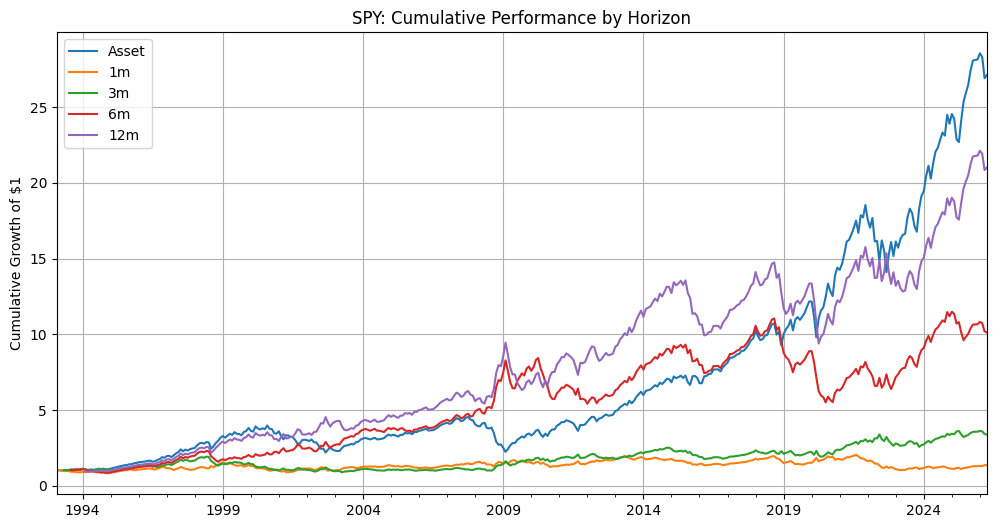

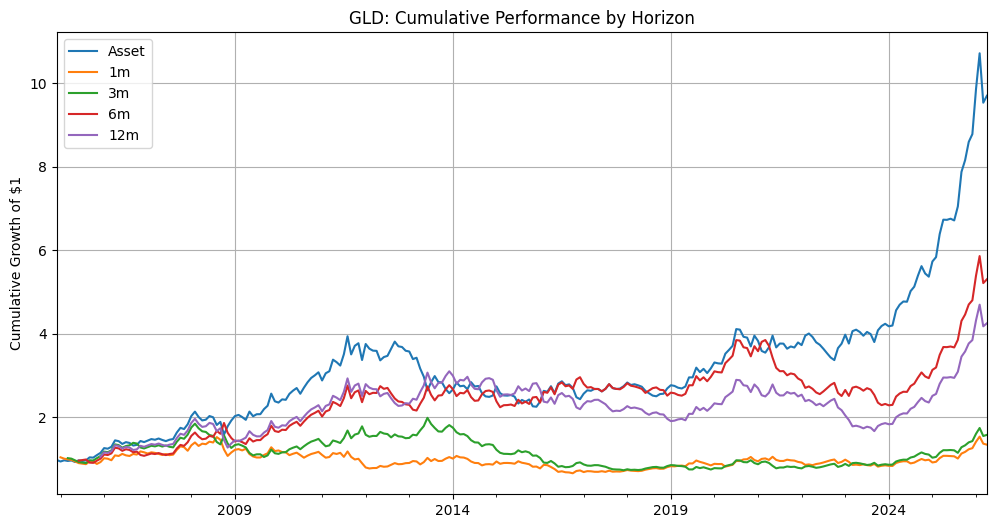

In [23]:
tickers_to_plot = ["SPY", "GLD"]

for ticker in tickers_to_plot:
    cum_by_horizon = pd.DataFrame({
        "Asset": (1 + r_m[ticker].dropna()).cumprod(),
        **{
            f"{k}m": (1 + strategy_returns_by_horizon[k][ticker].dropna()).cumprod()
            for k in horizons
        }
    })

    cum_by_horizon.plot(figsize=(12, 6), grid=True)
    plt.title(f"{ticker}: Cumulative Performance by Horizon")
    plt.ylabel("Cumulative Growth of $1")
    plt.xlabel("")
    plt.show()

### Turnover

**Turnover** here means how much the **position** changes month to month: $|\,p_t - p_{t-1}\,|$. For discrete long/short ($\pm 1$), a sign flip counts as $2$; no change is $0$. Averaging over time gives **mean monthly turnover** per asset and horizon—higher for fast signals (e.g. 1m), lower for slow ones (e.g. 12m).


In [24]:
def turnover(position: pd.Series | pd.DataFrame) -> pd.Series | pd.DataFrame:
    return position.diff().abs()

In [25]:
turnover_by_horizon = {
    k: turnover(positions[k])
    for k in horizons
}

avg_turnover = pd.DataFrame({
    f"{k}m": turnover_by_horizon[k].mean(axis=0)
    for k in horizons
}).T

avg_turnover

,SPY,BIL,IEF,TLT,GLD,BTC-USD
1m,0.866499,0.560000,0.939929,1.024735,1.003922,0.948905
3m,0.410127,0.304933,0.519573,0.483986,0.545455,0.444444
6m,0.219388,0.190909,0.388489,0.338129,0.328000,0.272727
12m,0.082902,0.130841,0.176471,0.213235,0.262295,0.126984
